<a href="https://colab.research.google.com/github/yonaanda/Analisis-Visualisasi-Data/blob/main/Tugas%205/House_Prices.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [30]:
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.metrics import mean_squared_error

In [31]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
sample_submission = pd.read_csv("sample_submission.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Sample submission shape:", sample_submission.shape)

display(train.head())
display(test.head())
display(sample_submission.head())

Train shape: (1460, 81)
Test shape: (1459, 80)
Sample submission shape: (1459, 2)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


,Id,SalePrice
0,1461,169277.052498
1,1462,187758.393989
2,1463,183583.683570
3,1464,179317.477511
4,1465,150730.079977


# EDA

In [32]:
train.shape

(1460, 81)

In [33]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

**Handling Missing Value**

In [34]:
data_train = train.copy()
data_test = test.copy()
none_cols = data_train.select_dtypes(include=['object']).columns
for col in none_cols:
    modus_train = data_train[col].mode()[0]
    data_train[col] = data_train[col].fillna('None')
    data_test[col] = data_test[col].fillna('None')

In [35]:
data_test['LotFrontage'] = data_test['LotFrontage'].fillna(data_test['LotFrontage'].median())
data_test['GarageYrBlt'] = data_test['GarageYrBlt'].fillna(data_test['YearBuilt'])
data_test['MasVnrArea'] = data_test['MasVnrArea'].fillna(0)
data_test['Electrical'] = data_test['Electrical'].fillna(data_test['Electrical'].mode()[0])

data_train['LotFrontage'] = data_train['LotFrontage'].fillna(data_train['LotFrontage'].median())
data_train['GarageYrBlt'] = data_train['GarageYrBlt'].fillna(data_train['YearBuilt'])
data_train['MasVnrArea'] = data_train['MasVnrArea'].fillna(0)
data_train['Electrical'] = data_train['Electrical'].fillna(data_train['Electrical'].mode()[0])

**Membuat Fitur Baru**

In [36]:
data_test['TotalSF'] = data_test['TotalBsmtSF'].fillna(0) + data_test['1stFlrSF'].fillna(0) + data_test['2ndFlrSF'].fillna(0)
data_test['TotalBath'] = data_test['FullBath'].fillna(0) + 0.5 * data_test['HalfBath'].fillna(0) + data_test['BsmtFullBath'].fillna(0) + 0.5 * data_test['BsmtHalfBath'].fillna(0)
data_test['TotalPorchSF'] = data_test['OpenPorchSF'].fillna(0) + data_test['EnclosedPorch'].fillna(0) + data_test['3SsnPorch'].fillna(0) + data_test['ScreenPorch'].fillna(0) + data_test['WoodDeckSF'].fillna(0)
data_test['HouseAge'] = data_test['YrSold'].fillna(0) - data_test['YearBuilt'].fillna(0)

data_train['TotalSF'] = data_train['TotalBsmtSF'].fillna(0) + data_train['1stFlrSF'].fillna(0) + data_train['2ndFlrSF'].fillna(0)
data_train['TotalBath'] = data_train['FullBath'].fillna(0) + 0.5 * data_train['HalfBath'].fillna(0) + data_train['BsmtFullBath'].fillna(0) + 0.5 * data_train['BsmtHalfBath'].fillna(0)
data_train['TotalPorchSF'] = data_train['OpenPorchSF'].fillna(0) + data_train['EnclosedPorch'].fillna(0) + data_train['3SsnPorch'].fillna(0) + data_train['ScreenPorch'].fillna(0) + data_train['WoodDeckSF'].fillna(0)
data_train['HouseAge'] = data_train['YrSold'].fillna(0) - data_train['YearBuilt'].fillna(0)

In [37]:
data_train.shape

(1460, 85)

In [38]:
data_train=data_train.drop(columns=["Id", "TotalBsmtSF", "1stFlrSF", "2ndFlrSF", "FullBath", "HalfBath", "BsmtFullBath", "BsmtHalfBath",
                                    "OpenPorchSF", "EnclosedPorch", "3SsnPorch", "ScreenPorch", "WoodDeckSF",
                                    "YrSold", "YearBuilt"],axis=1)
data_train.shape

(1460, 70)

In [39]:
data_test=data_test.drop(columns=["Id", "TotalBsmtSF", "1stFlrSF", "2ndFlrSF", "FullBath", "HalfBath", "BsmtFullBath", "BsmtHalfBath",
                                    "OpenPorchSF", "EnclosedPorch", "3SsnPorch", "ScreenPorch", "WoodDeckSF",
                                    "YrSold", "YearBuilt"],axis=1)
data_test.shape

(1459, 69)

**Memisahkan Fitur dan Target**

In [40]:
x_train_raw = data_train.drop(columns=['SalePrice'])
y_train = data_train['SalePrice']

x_test_raw = data_test.copy()

In [41]:
kolom_null = ['BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'GarageCars', 'GarageArea']
for col in kolom_null:
    x_test_raw[col] = x_test_raw[col].fillna(0)

**Encoding Variabel Kategorikal Menjadi Numeric**

In [42]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

categorical_cols = x_train_raw.select_dtypes(include=['object']).columns
for col in categorical_cols:
    le = LabelEncoder()
    x_train_raw[col] = x_train_raw[col].astype(str)
    x_test_raw[col] = x_test_raw[col].astype(str)

    if 'None' in x_test_raw[col].values and 'None' not in x_train_raw[col].values:
        modus_train = x_train_raw[col].mode()[0]
        x_test_raw[col] = x_test_raw[col].replace('None', modus_train)

    x_train_raw[col] = le.fit_transform(x_train_raw[col])

    le_dict = dict(zip(le.classes_, le.transform(le.classes_)))
    x_test_raw[col] = x_test_raw[col].apply(lambda x: le_dict.get(x, -1))

**Standardization**

In [43]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train_raw)
x_test_scaled = scaler.transform(x_test_raw)

**Dimension Reduction**

In [44]:
null_columns = x_test_raw.isnull().sum()
print(null_columns[null_columns > 0])

Series([], dtype: int64)


In [45]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.90, random_state=42)
x_train_pca = pca.fit_transform(x_train_scaled)
x_test_pca = pca.transform(x_test_scaled)
print(x_train_pca.shape)
print(x_test_pca.shape)

(1460, 45)
(1459, 45)


# Clustering

**Elbow Method**

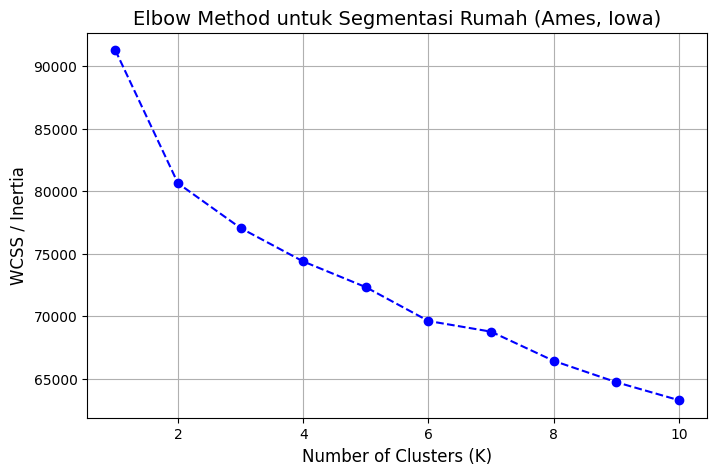

In [46]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 1. Menghitung nilai WCSS untuk cluster 1 sampai 10
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(x_train_pca)
    wcss.append(kmeans.inertia_)

# 2. Membuat plot grafik Elbow
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='blue')
plt.title('Elbow Method untuk Segmentasi Rumah (Ames, Iowa)', fontsize=14)
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('WCSS / Inertia', fontsize=12)
plt.grid(True)
plt.show()

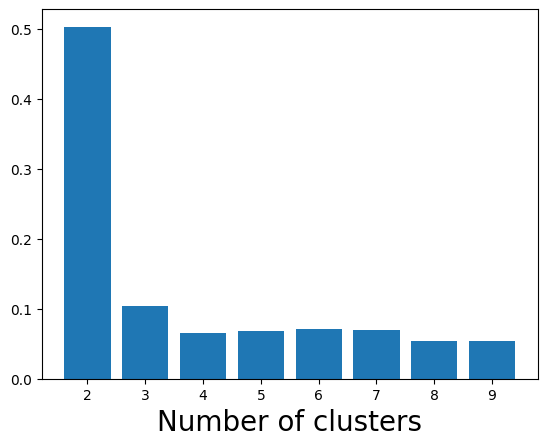

In [47]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for i in range(2,10):
    m1 = KMeans(n_clusters=i, random_state=42)
    c = m1.fit_predict(x_train_pca)
    silhouette_scores.append(silhouette_score(x_train_pca, c))
plt.bar(range(2,10), silhouette_scores)
plt.xlabel('Number of clusters', fontsize = 20)
plt.show()

In [48]:
kmeans_house = KMeans(n_clusters=2, random_state=42, n_init=10)
train_clusters = kmeans_house.fit_predict(x_train_pca)
data_train['Cluster_Rumah'] = train_clusters

print("Karakteristik Rata-Rata Tiap Kelompok Rumah")
print(data_train.groupby('Cluster_Rumah')[['SalePrice', 'TotalSF', 'OverallQual', 'HouseAge']].mean())

Karakteristik Rata-Rata Tiap Kelompok Rumah
                   SalePrice      TotalSF  OverallQual   HouseAge
Cluster_Rumah                                                    
0              135160.208845  2178.122850     5.240786  56.613022
1              238582.873065  3057.119195     7.181115  11.264706


# Build Model

In [49]:
# 1. Menentukan fitur (X) dan target (y)
X = x_train_raw.copy()
y = y_train

# 2. Membagi data menjadi 80% Train dan 20% Validation
X_train_mod, X_val_mod, y_train_mod, y_val_mod = train_test_split(
    X, y, test_size=0.2, random_state=42)

# 3. Melatih Model 1: Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_mod, y_train_mod)
rf_preds = rf_model.predict(X_val_mod)

# 4. Melatih Model 2: XGBoost Regressor Asli
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.05, random_state=42, max_depth=6)
xgb_model.fit(X_train_mod, y_train_mod)
xgb_preds = xgb_model.predict(X_val_mod)

# 5. Menampilkan Hasil Evaluasi (R2 Score & MAE)
print("=== PERFORMA MODEL RANDOM FOREST ===")
print(f"R2 Score (Akurasi)  : {r2_score(y_val_mod, rf_preds):.4f}")
print(f"Mean Absolute Error : ${mean_absolute_error(y_val_mod, rf_preds):,.2f}")

print("\n=== PERFORMA MODEL XGBOOST REGRESSOR ===")
print(f"R2 Score (Akurasi)  : {r2_score(y_val_mod, xgb_preds):.4f}")
print(f"Mean Absolute Error : ${mean_absolute_error(y_val_mod, xgb_preds):,.2f}")

=== PERFORMA MODEL RANDOM FOREST ===
R2 Score (Akurasi)  : 0.8862
Mean Absolute Error : $17,752.88

=== PERFORMA MODEL XGBOOST REGRESSOR ===
R2 Score (Akurasi)  : 0.8833
Mean Absolute Error : $17,054.54


In [50]:
# Memprediksi harga rumah pada data test menggunakan model XGBoost
final_preds = xgb_model.predict(x_test_raw)

submission = pd.read_csv('sample_submission.csv')
submission['SalePrice'] = final_preds
submission.to_csv('submission_house_price.csv', index=False)

print("--- PROSES SELESAI ---")

--- PROSES SELESAI ---


In [51]:
file_submission = pd.read_csv("submission_house_price.csv")
file_submission.head()

,Id,SalePrice
0,1461,126038.38
1,1462,167573.70
2,1463,172897.30
3,1464,190933.66
4,1465,189609.53
